<a href="https://colab.research.google.com/github/Areeba391391/Iris-Flower-Classification/blob/main/Iris_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


First 5 rows:
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Class distribution:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Predicted class

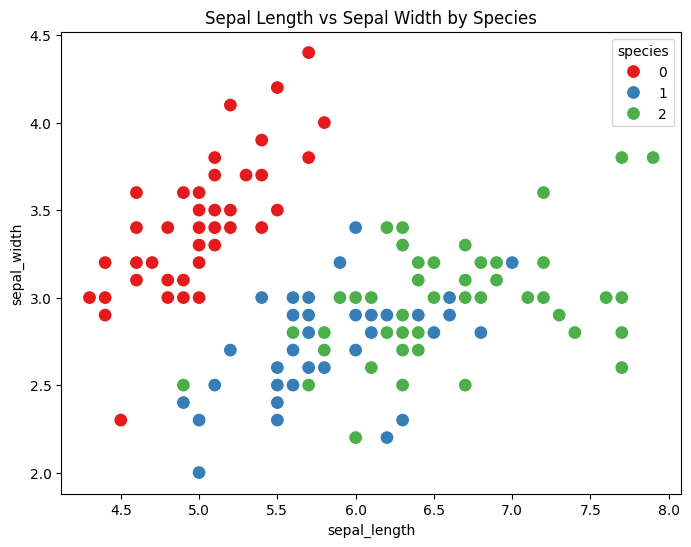

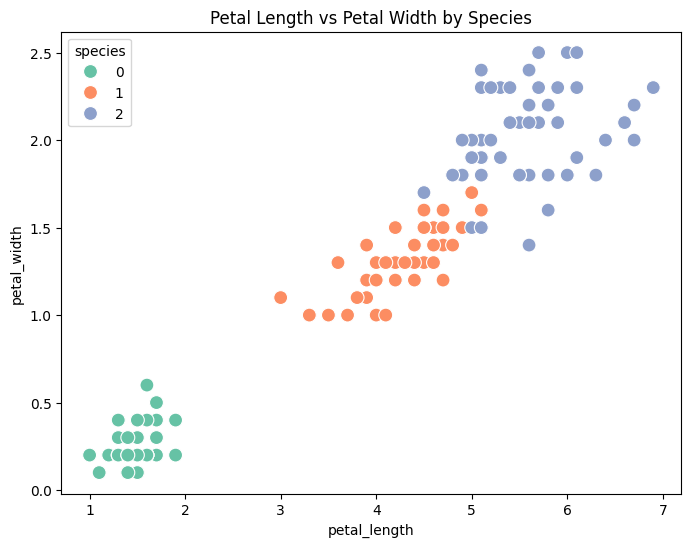

/tmp/ipykernel_892/3560934815.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


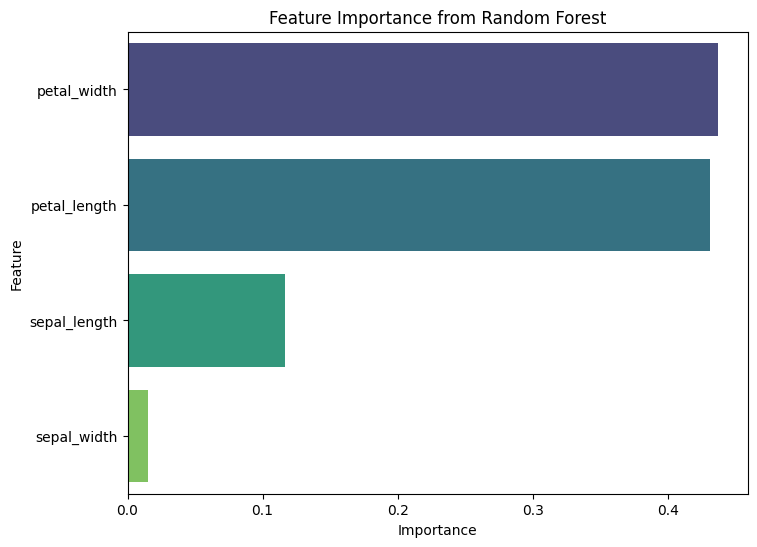

In [4]:
# Complete Iris Classification with Visualization
# Internship Task 4 - ARCH Technologies

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# Step 3: Explore dataset
print("First 5 rows:\n", df.head())
print("\nClass distribution:\n", df['species'].value_counts())

# Step 4: Encode target
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

# Step 5: Split features and target
X = df.drop('species', axis=1)
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 6: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 7: Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Step 8: Evaluate model
y_pred = model.predict(X_test_scaled)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 9: Sample prediction
sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)
sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)
print("\nPredicted class for sample:", le.inverse_transform(prediction)[0])

# Step 10: Visualization
# Scatter plot for sepal length vs sepal width
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', palette='Set1', s=100)
plt.title('Sepal Length vs Sepal Width by Species')
plt.show()

# Scatter plot for petal length vs petal width
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', s=100)
plt.title('Petal Length vs Petal Width by Species')
plt.show()

# Feature Importance from Random Forest
importances = model.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.show()